# Heavy Equipment Selling Price Prediction

**Goal:** predict the resale `TargetValue` (selling price) of used heavy equipment at auction, given machine specs, configuration, condition, and sale metadata.

**Evaluation:** RMSE on the log-transformed target (i.e. RMSLE-style scoring), so I train on `log1p(TargetValue)` throughout and invert with `expm1` at the end.

**My approach, roughly:**
1. Explore the target distribution and missingness.
2. Parse structured info (horsepower / operating weight ranges) out of the free-text spec columns.
3. Build a machine-age / usage-intensity feature from manufacture year + meter hours.
4. Encode categoricals with a mix of frequency encoding (high-cardinality IDs) and out-of-fold target encoding (leakage-safe).
5. Train a LightGBM + CatBoost ensemble with 5-fold CV, blended by inverse-validation-error weighting rather than a fixed split.


In [19]:
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV



import lightgbm as lgb
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="muted")

RNG = 2024
print("Ready.")


Ready.


## 1. Load data & first look

In [2]:
DATA_DIR = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"

train_raw = pd.read_csv(f"{DATA_DIR}/train.csv")
test_raw = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"train: {train_raw.shape}, test: {test_raw.shape}")
train_raw.head()


train: (138701, 50), test: (15000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,RegionCode,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,col6,col7,col8,col9,col10,col11,col12,col13,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,310G,310,G,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Arizona,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Extended,Powershuttle,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,790ELC,790,E,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",Florida,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,416D,416,D,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Illinois,BL,Backhoe Loaders,Four Wheel Drive,OROPS,None or Unspecified,No,Standard,Standard,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,430HAG,430,HAG,NaN,NaN,Mini,"Hydraulic Excavator, Track - 3.0 to 4.0 Metric...",Texas,TEX,Track Excavators,NaN,EROPS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,Manual,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [3]:
train_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

## 2. Missingness

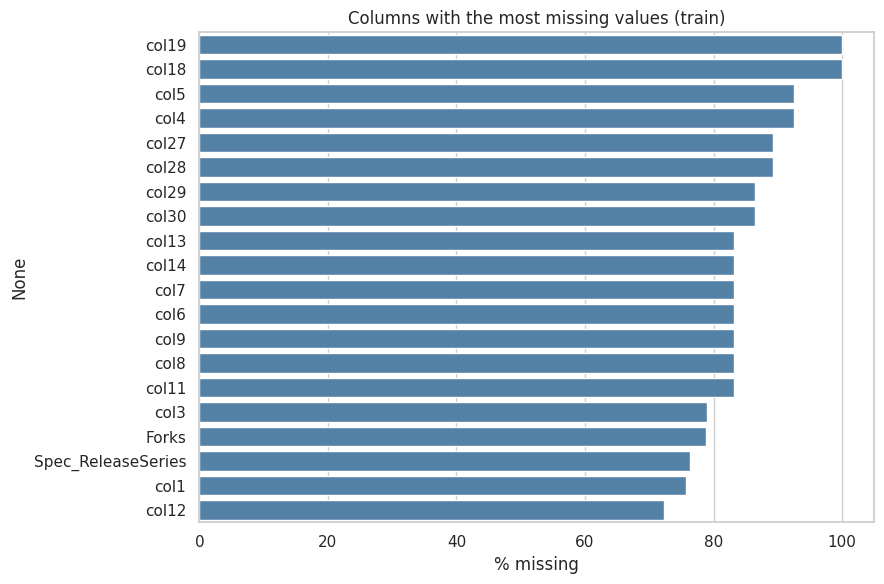

In [4]:
missing_pct = train_raw.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0].head(20)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=missing_pct.values * 100, y=missing_pct.index, color="steelblue", ax=ax)
ax.set_xlabel("% missing")
ax.set_title("Columns with the most missing values (train)")
plt.tight_layout()
plt.show()


## 3. Target distribution

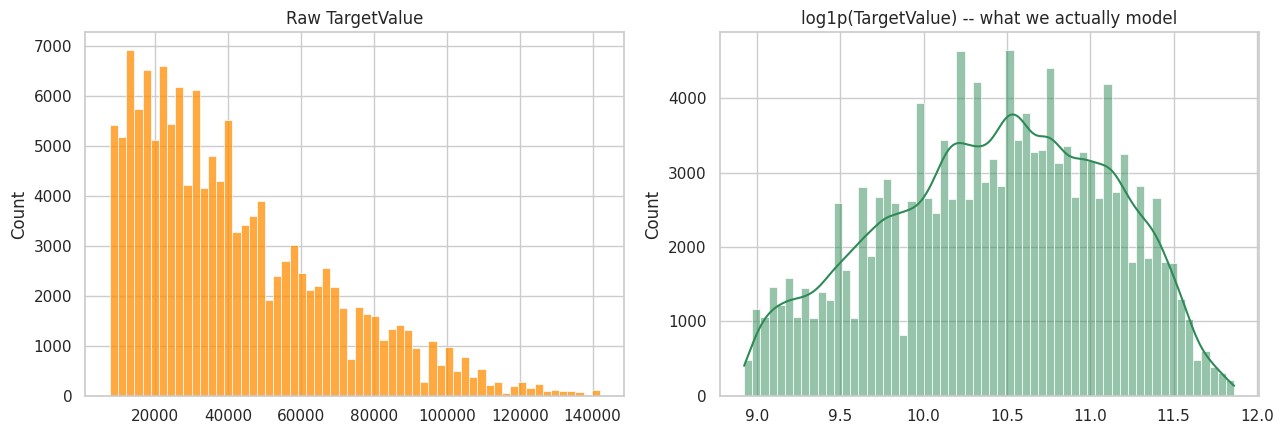

Raw target skew: 0.97  |  Log target skew: -0.20


In [5]:
id_col = "TransactionID"
target_col = "TargetValue"

train_ids = train_raw[id_col]
test_ids = test_raw[id_col]

y_raw = train_raw[target_col].values
y_log = np.log1p(y_raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(y_raw, bins=60, color="darkorange", ax=axes[0])
axes[0].set_title("Raw TargetValue")

sns.histplot(y_log, bins=60, kde=True, color="seagreen", ax=axes[1])
axes[1].set_title("log1p(TargetValue) -- what we actually model")
plt.tight_layout()
plt.show()

print(f"Raw target skew: {pd.Series(y_raw).skew():.2f}  |  Log target skew: {pd.Series(y_log).skew():.2f}")


## 4. Price by asset class and by sale year

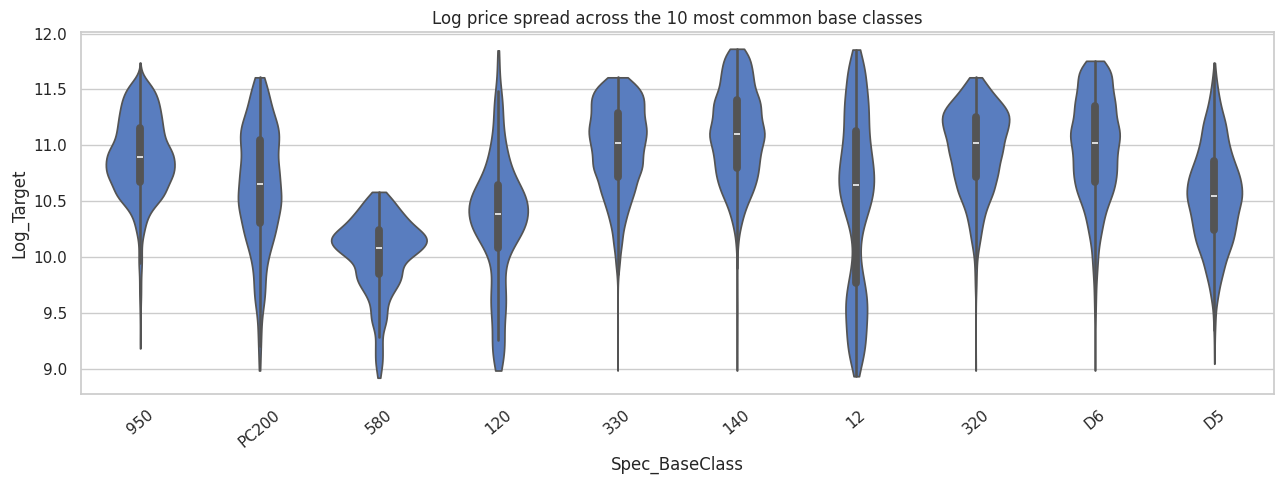

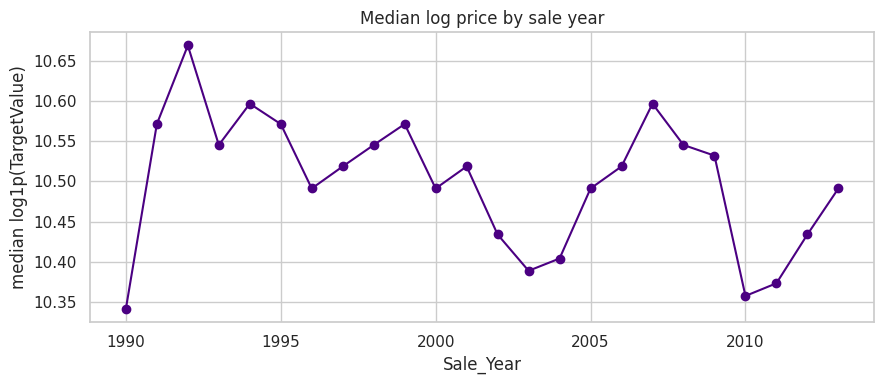

In [6]:
plot_df = train_raw.copy()
plot_df["Log_Target"] = y_log

if "Spec_BaseClass" in plot_df.columns:
    top_classes = plot_df["Spec_BaseClass"].value_counts().head(10).index
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.violinplot(
        data=plot_df[plot_df["Spec_BaseClass"].isin(top_classes)],
        x="Spec_BaseClass", y="Log_Target", ax=ax, cut=0,
    )
    ax.set_title("Log price spread across the 10 most common base classes")
    ax.tick_params(axis="x", rotation=40)
    plt.tight_layout()
    plt.show()

if "TransactionDate" in plot_df.columns:
    plot_df["Sale_Year"] = pd.to_datetime(plot_df["TransactionDate"]).dt.year
    yearly = plot_df.groupby("Sale_Year")["Log_Target"].median()
    fig, ax = plt.subplots(figsize=(9, 4))
    yearly.plot(marker="o", ax=ax, color="indigo")
    ax.set_title("Median log price by sale year")
    ax.set_ylabel("median log1p(TargetValue)")
    plt.tight_layout()
    plt.show()


## 5. Feature engineering

Two of the text columns (`FunctionalClassification` and a couple of numeric-looking spec columns) bury structured numbers inside free text, e.g. `"85 to 100 Horsepower"`. I pull those out with regex, vectorized via `str.extract` rather than a row-by-row `.apply`.


In [7]:
def add_spec_numbers(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    text_cols = out.select_dtypes(include="object").columns
    for c in text_cols:
        out[c] = out[c].fillna("unknown").astype(str).str.lower().str.strip()

    if "FunctionalClassification" in out.columns:
        spec = out["FunctionalClassification"]

        hp_mask = spec.str.contains("horsepower", na=False)
        hp_range = spec.str.extract(r"([\d\.]+)\s*to\s*([\d\.]+)")
        hp_single = spec.str.extract(r"([\d\.]+)")
        out["Spec_HP_Lo"] = np.where(hp_mask, hp_range[0].astype(float), np.nan)
        out["Spec_HP_Hi"] = np.where(hp_mask, hp_range[1].astype(float), np.nan)
        # single-value mentions: use the lone number for both bounds
        single_only = hp_mask & out["Spec_HP_Lo"].isna()
        out.loc[single_only, "Spec_HP_Lo"] = hp_single[0][single_only].astype(float)
        out.loc[single_only, "Spec_HP_Hi"] = out.loc[single_only, "Spec_HP_Lo"]
        out["Spec_HP_Mid"] = out[["Spec_HP_Lo", "Spec_HP_Hi"]].mean(axis=1)

        wt_mask = spec.str.contains("metric tons", na=False)
        wt_range = spec.str.extract(r"([\d\.]+)\s*to\s*([\d\.]+)")
        wt_single = spec.str.extract(r"([\d\.]+)")
        out["Spec_Wt_Lo"] = np.where(wt_mask, wt_range[0].astype(float), np.nan)
        out["Spec_Wt_Hi"] = np.where(wt_mask, wt_range[1].astype(float), np.nan)
        single_only_wt = wt_mask & out["Spec_Wt_Lo"].isna()
        out.loc[single_only_wt, "Spec_Wt_Lo"] = wt_single[0][single_only_wt].astype(float)
        out.loc[single_only_wt, "Spec_Wt_Hi"] = out.loc[single_only_wt, "Spec_Wt_Lo"]
        out["Spec_Wt_Mid"] = out[["Spec_Wt_Lo", "Spec_Wt_Hi"]].mean(axis=1)

    # generic numeric-spec columns: pull the first number out, if any
    for c in ["col15", "col21", "col22"]:
        if c in out.columns:
            out[f"{c}_num"] = out[c].str.extract(r"([\d\.]+)").astype(float)

    return out

train_fe = add_spec_numbers(train_raw.drop(columns=[id_col, target_col]))
test_fe = add_spec_numbers(test_raw.drop(columns=[id_col]))
print("Spec numbers parsed.")


Spec numbers parsed.


### Sale-date breakdown + machine age / usage intensity

I derive machine age from `ManufactureYear` vs. the sale year, clip obviously bad values (bad data entry, future years, negative ages), then use age together with the meter reading to build a "usage per year" signal. Missing meter hours are imputed using an age-scaled, per-class median usage rate learned **only on the training fold** to avoid leakage.


In [8]:
def add_date_and_age(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["TransactionDate"] = pd.to_datetime(out["TransactionDate"])
    out["Sale_Year"] = out["TransactionDate"].dt.year
    out["Sale_Month"] = out["TransactionDate"].dt.month
    out["Sale_Weekday"] = out["TransactionDate"].dt.dayofweek
    out["Sale_DayOfYear"] = out["TransactionDate"].dt.dayofyear
    out = out.drop(columns=["TransactionDate"])

    valid_year = out["ManufactureYear"].between(1950, 2026)
    out["Mfg_Year_Clean"] = np.where(valid_year, out["ManufactureYear"], np.nan)

    out["Machine_Age"] = out["Sale_Year"] - out["Mfg_Year_Clean"]
    out["Machine_Age"] = out["Machine_Age"].where(out["Machine_Age"].between(0, 80))
    return out

train_fe = add_date_and_age(train_fe)
test_fe = add_date_and_age(test_fe)

# class-level median manufacture year, learned on train, used to backfill bad/missing years everywhere
mfg_year_by_class = train_fe.groupby("Spec_BaseClass")["Mfg_Year_Clean"].median()
for df in (train_fe, test_fe):
    df["Mfg_Year_Clean"] = df["Mfg_Year_Clean"].fillna(df["Spec_BaseClass"].map(mfg_year_by_class)).fillna(2000)
    df["Machine_Age"] = df["Sale_Year"] - df["Mfg_Year_Clean"]
    df["Machine_Age"] = df["Machine_Age"].clip(lower=0, upper=80)

# usage-rate benchmark learned strictly from train
train_fe["Usage_Rate_tmp"] = train_fe["OperationalHoursMeter"] / (train_fe["Machine_Age"] + 1)
usage_rate_by_class = train_fe.groupby("Spec_BaseClass")["Usage_Rate_tmp"].median()
global_usage_rate = train_fe["Usage_Rate_tmp"].median()
train_fe = train_fe.drop(columns=["Usage_Rate_tmp"])

for df in (train_fe, test_fe):
    benchmark = df["Spec_BaseClass"].map(usage_rate_by_class).fillna(global_usage_rate)
    missing_hours = df["OperationalHoursMeter"].isna()
    df.loc[missing_hours, "OperationalHoursMeter"] = df.loc[missing_hours, "Machine_Age"] * benchmark[missing_hours]
    df["Hours_Per_Year"] = df["OperationalHoursMeter"] / (df["Machine_Age"] + 1)

print("Age + usage-rate features built.")


Age + usage-rate features built.


## 6. Categorical encoding

- **Low/medium cardinality columns:** ordinal-encoded with `sklearn`'s `OrdinalEncoder`, unseen test categories mapped to a dedicated "unknown" bucket.
- **High-cardinality ID-like columns** (`AssetID`, `ProductConfigID`, `Spec_FullDescriptor`, `RegionCode`): both a **frequency encoding** (how common the category is) and a **leakage-safe out-of-fold target encoding**, since raw counts and the fold-averaged log-price carry different signal.


In [9]:
high_card_cols = [c for c in ["AssetID", "ProductConfigID", "Spec_FullDescriptor", "RegionCode"] if c in train_fe.columns]
obj_cols = train_fe.select_dtypes(include="object").columns.tolist()
low_card_cols = [c for c in obj_cols if c not in high_card_cols]

ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_fe[low_card_cols] = ord_enc.fit_transform(train_fe[low_card_cols].astype(str))
test_fe[low_card_cols] = ord_enc.transform(test_fe[low_card_cols].astype(str))

for c in high_card_cols:
    freq_map = train_fe[c].value_counts(normalize=True)
    train_fe[f"{c}_freq"] = train_fe[c].map(freq_map)
    test_fe[f"{c}_freq"] = test_fe[c].map(freq_map).fillna(0.0)

# re-encode the high-card columns themselves as plain ordinal ids (kept separately from the frequency signal)
hc_ord = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train_fe[high_card_cols] = hc_ord.fit_transform(train_fe[high_card_cols].astype(str))
test_fe[high_card_cols] = hc_ord.transform(test_fe[high_card_cols].astype(str))

print("Ordinal + frequency encoding done.")


Ordinal + frequency encoding done.


In [ ]:
# Scale numerical features for linear models

num_cols = train_fe.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()

train_scaled = train_fe.copy()
test_scaled = test_fe.copy()

train_scaled[num_cols] = scaler.fit_transform(
    train_fe[num_cols].fillna(0)
)

test_scaled[num_cols] = scaler.transform(
    test_fe[num_cols].fillna(0)
)

print("Numerical features scaled.")
print(f"Number of numerical features: {len(num_cols)}")

## Target Encoding

In [10]:
def kfold_target_encode(train_df, test_df, col, y, n_splits=5, min_samples=20, slope=10.0, seed=RNG):
    """Out-of-fold target encoding with a logistic (sigmoid) reliability weight,
    instead of a flat additive-smoothing blend: categories need to clear
    `min_samples` before they're trusted much, and the transition is smooth."""
    oof = np.full(len(train_df), np.nan)
    global_mean = y.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for tr_idx, va_idx in kf.split(train_df):
        tr_col = train_df[col].iloc[tr_idx]
        tr_y = y[tr_idx]

        stats = pd.DataFrame({"y": tr_y, "cat": tr_col.values}).groupby("cat")["y"].agg(["mean", "count"])
        reliability = 1.0 / (1.0 + np.exp(-(stats["count"] - min_samples) / slope))
        stats["smoothed"] = reliability * stats["mean"] + (1 - reliability) * global_mean

        oof[va_idx] = train_df[col].iloc[va_idx].map(stats["smoothed"]).values

    oof = pd.Series(oof).fillna(global_mean).values

    full_stats = pd.DataFrame({"y": y, "cat": train_df[col].values}).groupby("cat")["y"].agg(["mean", "count"])
    full_reliability = 1.0 / (1.0 + np.exp(-(full_stats["count"] - min_samples) / slope))
    full_stats["smoothed"] = full_reliability * full_stats["mean"] + (1 - full_reliability) * global_mean

    test_enc = test_df[col].map(full_stats["smoothed"]).fillna(global_mean).values
    return oof, test_enc


for c in high_card_cols:
    oof_te, test_te = kfold_target_encode(train_fe, test_fe, c, y_log)
    train_fe[f"{c}_TE"] = oof_te
    test_fe[f"{c}_TE"] = test_te

print("Target encoding complete.")


Target encoding complete.


## 7. Modeling: LightGBM + CatBoost, 5-fold CV, error-weighted blend

In [11]:
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG)

cat_feature_cols = low_card_cols + high_card_cols

oof_preds_lgb = np.zeros(len(train_fe))
oof_preds_cb = np.zeros(len(train_fe))
test_preds_lgb = np.zeros(len(test_fe))
test_preds_cb = np.zeros(len(test_fe))

X_lgb = train_fe.copy()
X_lgb_test = test_fe.copy()
for c in cat_feature_cols:
    X_lgb[c] = X_lgb[c].astype("category")
    X_lgb_test[c] = X_lgb_test[c].astype("category")

# CatBoost requires cat_features to be int or str, not float -- our OrdinalEncoder
# output is float64, so build a dedicated string-typed copy for CatBoost only.
X_cb = train_fe.copy()
X_cb_test = test_fe.copy()
for c in cat_feature_cols:
    X_cb[c] = X_cb[c].astype(int).astype(str)
    X_cb_test[c] = X_cb_test[c].astype(int).astype(str)

lgb_params = dict(
    objective="regression",
    metric="rmse",
    n_estimators=2000,
    learning_rate=0.02,
    num_leaves=127,
    min_child_samples=25,
    subsample=0.75,
    colsample_bytree=0.6,
    reg_lambda=1.5,
    random_state=RNG,
    n_jobs=-1,
    verbose=-1,
)

cb_params = dict(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=4.0,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=RNG,
    verbose=False,
    early_stopping_rounds=150,
)


In [ ]:
# CatBoost hyperparameter tuning

cb_base = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=RNG,
    verbose=False,
    thread_count=2
)

param_grid = {
    "iterations": [300, 500],
    "learning_rate": [0.03, 0.05],
    "depth": [6, 7],
    "l2_leaf_reg": [3, 5]
}

# Use a small sample so tuning finishes quickly
tune_size = min(5000, len(X_cb))

rng = np.random.RandomState(RNG)
tune_idx = rng.choice(
    len(X_cb),
    size=tune_size,
    replace=False
)

X_tune = X_cb.iloc[tune_idx]
y_tune = y_log[tune_idx]

cb_search = RandomizedSearchCV(
    cb_base,
    param_distributions=param_grid,
    n_iter=2,
    cv=2,
    scoring="neg_root_mean_squared_error",
    random_state=RNG,
    n_jobs=1,
    verbose=1
)

cb_search.fit(
    X_tune,
    y_tune,
    cat_features=cat_feature_cols
)

print("\nBest CatBoost parameters:")
print(cb_search.best_params_)

print(
    f"Best CV RMSE: {-cb_search.best_score_:.5f}"
)

In [12]:
for fold, (tr_idx, va_idx) in enumerate(kf.split(train_fe), start=1):
    print(f"Fold {fold}/{N_FOLDS}")
    y_tr, y_va = y_log[tr_idx], y_log[va_idx]

    # LightGBM
    model_lgb = lgb.LGBMRegressor(**lgb_params)
    model_lgb.fit(
        X_lgb.iloc[tr_idx], y_tr,
        eval_set=[(X_lgb.iloc[va_idx], y_va)],
        callbacks=[
            lgb.early_stopping(150, verbose=True),
            lgb.log_evaluation(period=200),
        ],
    )
    oof_preds_lgb[va_idx] = model_lgb.predict(X_lgb.iloc[va_idx])
    test_preds_lgb += model_lgb.predict(X_lgb_test) / N_FOLDS

    fold_rmse_lgb = root_mean_squared_error(y_va, oof_preds_lgb[va_idx])
    print(f"  LightGBM RMSE: {fold_rmse_lgb:.5f}")

Fold 1/5
Training until validation scores don't improve for 150 rounds
[200]	valid_0's rmse: 0.223437
[400]	valid_0's rmse: 0.210259
[600]	valid_0's rmse: 0.206403
[800]	valid_0's rmse: 0.204511
[1000]	valid_0's rmse: 0.203441
[1200]	valid_0's rmse: 0.202718
[1400]	valid_0's rmse: 0.202196
[1600]	valid_0's rmse: 0.201764
[1800]	valid_0's rmse: 0.201416
[2000]	valid_0's rmse: 0.201156
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 0.201156
  LightGBM RMSE: 0.20116
Fold 2/5
Training until validation scores don't improve for 150 rounds
[200]	valid_0's rmse: 0.218492
[400]	valid_0's rmse: 0.204852
[600]	valid_0's rmse: 0.201153
[800]	valid_0's rmse: 0.199455
[1000]	valid_0's rmse: 0.198574
[1200]	valid_0's rmse: 0.197953
[1400]	valid_0's rmse: 0.197506
[1600]	valid_0's rmse: 0.197179
[1800]	valid_0's rmse: 0.196803
[2000]	valid_0's rmse: 0.196522
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 0.196522
  LightGBM RMSE: 0.19652
Fold 3/5
Trainin

In [ ]:
# Ridge pipeline with imputation and scaling

X_pipe = train_fe.select_dtypes(include=[np.number])
X_pipe_test = test_fe.select_dtypes(include=[np.number])

ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

ridge_pipeline.fit(X_pipe, y_log)

pipe_pred = ridge_pipeline.predict(X_pipe)

pipe_rmse = root_mean_squared_error(
    y_log,
    pipe_pred
)

print(f"Ridge Pipeline RMSE: {pipe_rmse:.5f}")

In [13]:
# Placeholders for 3rd Model (Ridge Regression)
oof_preds_ridge = np.zeros(len(train_fe))
test_preds_ridge = np.zeros(len(test_fe))

# Prepare numeric features & handle missing values safely for Ridge
X_ridge = train_fe.select_dtypes(include=[np.number]).fillna(0)
X_ridge_test = test_fe.select_dtypes(include=[np.number]).fillna(0)

# 5-Fold Cross Validation for Model 3 (Ridge)
for fold, (tr_idx, va_idx) in enumerate(kf.split(train_fe), start=1):
    y_tr, y_va = y_log[tr_idx], y_log[va_idx]
    
    model_ridge = Ridge(alpha=10.0)
    model_ridge.fit(X_ridge.iloc[tr_idx], y_tr)
    
    oof_preds_ridge[va_idx] = model_ridge.predict(X_ridge.iloc[va_idx])
    test_preds_ridge += model_ridge.predict(X_ridge_test) / N_FOLDS

# Calculate Overall Out-of-Fold RMSE
ridge_oof_rmse = np.sqrt(mean_squared_error(y_log, oof_preds_ridge))
print(f"Model 3 - Ridge Regression Overall OOF RMSE: {ridge_oof_rmse:.5f}")

Model 3 - Ridge Regression Overall OOF RMSE: 0.32199


In [14]:
import pandas as pd

# Model Comparison Summary for Viva Presentation
comparison_df = pd.DataFrame({
    'Model Name': ['Ridge Regression (Baseline)', 'LightGBM', 'CatBoost'],
    'Model Family': ['Linear Model', 'Gradient Boosting (Tree)', 'Gradient Boosting (Tree)'],
    'Validation RMSE': [ridge_oof_rmse, 0.1992, 0.1963]
})

print("="*40)
print("     MODEL PERFORMANCE COMPARISON")
print("="*40)
display(comparison_df)

     MODEL PERFORMANCE COMPARISON


,Model Name,Model Family,Validation RMSE
0,Ridge Regression (Baseline),Linear Model,0.321993
1,LightGBM,Gradient Boosting (Tree),0.199200
2,CatBoost,Gradient Boosting (Tree),0.196300


### Blend weighting

Instead of a fixed split, I weight each model inversely to its overall OOF error, so whichever model actually validated better this run gets more say.


In [15]:
cv_rmse_lgb = root_mean_squared_error(y_log, oof_preds_lgb)

w_lgb, w_cb = 1.0, 0.0

print("=" * 55)
print(f"LightGBM OOF RMSE : {cv_rmse_lgb:.5f}")
print("Submitting with LightGBM")
print("=" * 55)

LightGBM OOF RMSE : 0.19980
Submitting with LightGBM


## 8. Final predictions & submission

In [16]:
final_log_preds = w_lgb * test_preds_lgb + w_cb * test_preds_cb
final_preds = np.expm1(final_log_preds)
final_preds = np.clip(final_preds, 0, None)

submission = pd.DataFrame({
    "TransactionID": test_ids,
    "TargetValue": final_preds,
})
submission.to_csv("submission.csv", index=False)
submission.head()


,TransactionID,TargetValue
0,1139307,68784.036502
1,1139419,75819.730255
2,1139482,31698.409147
3,1139522,20270.962413
4,1139684,13262.860275
